# HW1 Вариант B: Трекинг-модуль (Lucas–Kanade и Farnebäck)

In [ ]:
# Imports and config
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

VIDEO_LIST = ["in_videos/shapes.mp4", "in_videos/ants.mp4"]
OUT_DIR = "out"
OUT_VIDEOS = os.path.join(OUT_DIR, "videos")
OUT_PICTURES = os.path.join(OUT_DIR, "pictures")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(OUT_VIDEOS, exist_ok=True)
os.makedirs(OUT_PICTURES, exist_ok=True)

MAX_FRAMES, RESIZE_WIDTH, FPS_OUT = 150, 960, 30
GAUSS_BLUR, USE_CLAHE = (5, 5), True

GFTT_PARAMS = dict(maxCorners=500, qualityLevel=0.01, minDistance=7, blockSize=7)
LK_PARAMS = dict(winSize=(21, 21), maxLevel=3, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
LK_ERR_THRESH, LK_MAX_JUMP = 20.0, 60.0
REDETECT_PCT = 0

FB_PARAMS = dict(pyr_scale=0.5, levels=3, winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
# Motion mask: mag > thresh, morphology, min area
MAG_THRESH, MORPH_KERNEL, MIN_COMPONENT_AREA = 1.5, 5, 150


In [10]:
def resize_keep_aspect(frame, width):
    if width is None or frame.shape[1] == width:
        return frame
    h, w = frame.shape[:2]
    return cv2.resize(frame, (width, int(h * width / w)), interpolation=cv2.INTER_AREA)

def preprocess_gray(frame_bgr):
    frame_bgr = resize_keep_aspect(frame_bgr, RESIZE_WIDTH)
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    if GAUSS_BLUR:
        gray = cv2.GaussianBlur(gray, GAUSS_BLUR, 0)
    if USE_CLAHE:
        gray = cv2.createCLAHE(2.0, (8, 8)).apply(gray)
    return frame_bgr, gray


def flow_to_hsv_bgr(flow):
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1], angleInDegrees=True)
    hsv = np.zeros((*flow.shape[:2], 3), dtype=np.uint8)
    hsv[..., 0], hsv[..., 1] = (ang / 2).astype(np.uint8), 255
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR), mag

def clean_motion_mask(mask):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL, MORPH_KERNEL))
    mask = cv2.morphologyEx(cv2.morphologyEx(mask, cv2.MORPH_OPEN, k), cv2.MORPH_CLOSE, k, iterations=2)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= MIN_COMPONENT_AREA:
            out[labels == i] = 255
    return out


TRACK_PALETTE = [
    (0, 255, 0), (0, 255, 255), (255, 0, 0), (255, 128, 0), (255, 0, 255),
    (0, 165, 255), (0, 128, 255), (128, 0, 255), (255, 255, 0), (128, 255, 0),
    (255, 0, 128), (0, 200, 200), (200, 0, 200), (200, 200, 0), (50, 205, 154),
    (255, 165, 0), (147, 20, 255), (255, 192, 203), (176, 224, 230), (255, 215, 0),
]
INITIAL_COLOR = (0, 255, 0)
REACQUIRED_PALETTE = [c for c in TRACK_PALETTE if c != INITIAL_COLOR] or [(0, 255, 255)]

def draw_lk_tracks(frame, tracks, track_colors):
    vis = frame.copy()
    for tr, color in zip(tracks, track_colors):
        if len(tr) < 2:
            continue
        pts = np.array(tr, dtype=np.int32)
        cv2.polylines(vis, [pts], False, color, 1, cv2.LINE_AA)
        cv2.circle(vis, tuple(pts[-1]), 4, (0, 0, 0), -1, cv2.LINE_AA)
    return vis

def track_lk_step(prev_gray, gray, tracks, alive, track_colors, redetect_thresh, new_pts_fn):
    """One LK step + optional re-detect. Updates tracks, alive, track_colors in place; returns alive."""
    idx = np.where(alive)[0]
    if len(idx) > 0:
        prev_pts = np.array([tracks[i][-1] for i in idx], dtype=np.float32).reshape(-1, 1, 2)
        next_pts, st, err = cv2.calcOpticalFlowPyrLK(prev_gray, gray, prev_pts, None, **LK_PARAMS)
        good = st.ravel().astype(bool) & (err.ravel() < LK_ERR_THRESH)
        good &= np.linalg.norm((next_pts - prev_pts).reshape(-1, 2), axis=1) < LK_MAX_JUMP
        for j, i in enumerate(idx):
            if good[j]:
                tracks[i].append(tuple(next_pts[j, 0]))
            else:
                alive[i] = False
    if alive.sum() < redetect_thresh:
        pts = new_pts_fn(gray)
        n_add = min(200, len(pts))
        for pt in pts[:n_add]:
            tracks.append(deque([tuple(pt)], maxlen=MAX_FRAMES))
            track_colors.append(random.choice(REACQUIRED_PALETTE))
        alive = np.concatenate([alive, np.ones(n_add, dtype=bool)])
    return alive

In [11]:
def get_gftt_pts(g):
    p = cv2.goodFeaturesToTrack(g, mask=None, **GFTT_PARAMS)
    return p.reshape(-1, 2) if p is not None else np.zeros((0, 2))


def _open_video_and_first_frame(video_path):
    """Open video, read first frame; return (cap, frame_bgr, prev_gray, h, w) or (None,)*5."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Skip {video_path}: cannot open")
        return None, None, None, None, None
    ret, frame0 = cap.read()
    if not ret:
        print(f"Skip {video_path}: empty")
        cap.release()
        return None, None, None, None, None
    frame_bgr, prev_gray = preprocess_gray(frame0)
    h, w = frame_bgr.shape[:2]
    return cap, frame_bgr, prev_gray, h, w


def _init_lk_tracks(prev_gray):
    """Build tracks, colors, alive from GFTT on prev_gray; return (tracks, track_colors, alive, n_initial) or None."""
    p0 = cv2.goodFeaturesToTrack(prev_gray, mask=None, **GFTT_PARAMS)
    if p0 is None:
        return None
    p0 = p0.reshape(-1, 1, 2)
    tracks = [deque([tuple(pt.ravel())], maxlen=MAX_FRAMES) for pt in p0]
    track_colors = [INITIAL_COLOR] * len(tracks)
    alive = np.ones(len(p0), dtype=bool)
    return tracks, track_colors, alive, len(tracks)


def _create_video_writers(out_v, w, h):
    """Create writers for 3 outputs: lk_tracks (LK trails overlay), farneback_flow (flow HSV),
    motion_mask (binary mask: white = pixels where flow magnitude > MAG_THRESH, after morphology)."""
    fourcc = cv2.VideoWriter_fourcc(*"MJPG")
    return {
        "lk": cv2.VideoWriter(os.path.join(out_v, "lk_tracks.avi"), fourcc, FPS_OUT, (w, h)),
        "flow": cv2.VideoWriter(os.path.join(out_v, "farneback_flow.avi"), fourcc, FPS_OUT, (w, h)),
        "mask": cv2.VideoWriter(os.path.join(out_v, "motion_mask.avi"), fourcc, FPS_OUT, (w, h)),
    }


def _lk_frame_metrics(tracks, alive, jump_thr=25.0):
    """From current tracks/alive: mean displacement and jump ratio (displacement > jump_thr) per alive point."""
    disps = []
    jumps = 0
    for i in range(len(tracks)):
        if not alive[i] or len(tracks[i]) < 2:
            continue
        d = float(np.linalg.norm(np.array(tracks[i][-1]) - np.array(tracks[i][-2])))
        disps.append(d)
        if d > jump_thr:
            jumps += 1
    n_alive = max(1, int(alive.sum()))
    mean_disp = float(np.mean(disps)) if disps else 0.0
    jump_ratio = jumps / n_alive
    return mean_disp, jump_ratio


def _flow_and_mask_frame(prev_gray, gray):
    """Farneback flow + magnitude/mask stats. Returns (flow_bgr, mean_mag, p95_mag, mask, mask_area_ratio, n_components)."""
    flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None, **FB_PARAMS)
    flow_bgr, mag = flow_to_hsv_bgr(flow)
    mask = clean_motion_mask((mag > MAG_THRESH).astype(np.uint8) * 255)
    mean_mag = float(np.mean(mag))
    p95_mag = float(np.percentile(mag, 95))
    mask_area_ratio = (mask > 0).sum() / mask.size
    n_cc, _, _, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    return flow_bgr, mean_mag, p95_mag, mask, mask_area_ratio, n_cc - 1


def _write_frame_videos(writers, frame_bgr, tracks, track_colors, n_initial, n_alive, frame_idx, flow_bgr, mask):
    """Draw LK overlay with text, then write lk, flow, mask frames to writers."""
    pct = 100.0 * n_alive / n_initial if n_initial else 0
    txt = f"Frame {frame_idx+1}  Init: {n_initial}  Alive: {n_alive}  {pct:.1f}%"
    lk_vis = draw_lk_tracks(frame_bgr, tracks, track_colors)
    cv2.putText(lk_vis, txt, (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2, cv2.LINE_AA)
    cv2.putText(lk_vis, txt, (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)
    writers["lk"].write(lk_vis)
    writers["flow"].write(flow_bgr)
    writers["mask"].write(cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR))


def _process_frames(cap, writers, tracks, alive, track_colors, n_initial, prev_gray):
    """Run main loop: LK + Farneback per frame; return frame_count and all per-frame lists."""
    JUMP_THR = 25.0
    redetect_thresh = max(1, int(REDETECT_PCT * n_initial))
    survival_rates, mean_track_lens = [], []
    mask_area_ratios, mask_num_components = [], []
    alive_counts, mean_disp_list, jump_ratio_list, mean_mag_list, p95_mag_list = [], [], [], [], []
    gray = prev_gray
    for frame_count in range(MAX_FRAMES - 1):
        ret, frame = cap.read()
        if not ret:
            break
        frame_bgr, gray = preprocess_gray(frame)
        alive = track_lk_step(prev_gray, gray, tracks, alive, track_colors, redetect_thresh, get_gftt_pts)
        n_alive = int(alive.sum())
        alive_counts.append(n_alive)
        mean_disp, jump_ratio = _lk_frame_metrics(tracks, alive, JUMP_THR)
        mean_disp_list.append(mean_disp)
        jump_ratio_list.append(jump_ratio)
        flow_bgr, mean_mag, p95_mag, mask, mask_area_ratio, n_cc = _flow_and_mask_frame(prev_gray, gray)
        mean_mag_list.append(mean_mag)
        p95_mag_list.append(p95_mag)
        mask_area_ratios.append(mask_area_ratio)
        mask_num_components.append(n_cc)
        _write_frame_videos(writers, frame_bgr, tracks, track_colors, n_initial, n_alive, frame_count, flow_bgr, mask)
        survival_rates.append(alive.sum() / max(1, len(alive)))
        lengths = [len(tracks[i]) for i in range(len(tracks)) if alive[i]]
        mean_track_lens.append(np.mean(lengths) if lengths else 0.0)
        prev_gray = gray.copy()
    return (
        frame_count + 1,
        alive_counts, survival_rates, mean_track_lens,
        mask_area_ratios, mask_num_components,
        mean_disp_list, jump_ratio_list, mean_mag_list, p95_mag_list,
        alive,
    )


def _write_metrics_and_plot(name, out_dir, out_p, metrics, alive_counts, n_initial):
    """Write metrics txt and save survival plot."""
    with open(os.path.join(out_dir, f"{name}_metrics.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(f"{k}: {v}" for k, v in metrics.items()))
    fig, ax = plt.subplots(figsize=(8, 4))
    frames = np.arange(1, len(alive_counts) + 1)
    ax.plot(frames, alive_counts, label="Alive")
    ax.axhline(n_initial, color="gray", linestyle="--", label="Initial")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Points")
    ax.set_title(f"Track survival — {name}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(out_p, "metrics_by_frame.png"), dpi=100, bbox_inches="tight")
    plt.close(fig)


def _save_sample_frames(out_v, out_p):
    """Save sample frames (first, mid, last) from each output video."""
    for vname, fname in [("lk_tracks", "lk_tracks.avi"), ("farneback_flow", "farneback_flow.avi"), ("motion_mask", "motion_mask.avi")]:
        cap_out = cv2.VideoCapture(os.path.join(out_v, fname))
        if cap_out.isOpened():
            n = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))
            for idx in ([0, n // 2, n - 1] if n >= 3 else [0]):
                cap_out.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ok, img = cap_out.read()
                if ok:
                    cv2.imwrite(os.path.join(out_p, f"{vname}_frame{idx}.png"), img)
            cap_out.release()





In [12]:
TRACK_PALETTE = [
    (0, 255, 0), (0, 255, 255), (255, 0, 0), (255, 128, 0), (255, 0, 255),
    (0, 165, 255), (0, 128, 255), (128, 0, 255), (255, 255, 0), (128, 255, 0),
    (255, 0, 128), (0, 200, 200), (200, 0, 200), (200, 200, 0), (50, 205, 154),
    (255, 165, 0), (147, 20, 255), (255, 192, 203), (176, 224, 230), (255, 215, 0),
]
INITIAL_COLOR = (0, 255, 0)
REACQUIRED_PALETTE = [c for c in TRACK_PALETTE if c != INITIAL_COLOR] or [(0, 255, 255)]

def draw_lk_tracks(frame, tracks, track_colors):
    vis = frame.copy()
    for tr, color in zip(tracks, track_colors):
        if len(tr) < 2:
            continue
        pts = np.array(tr, dtype=np.int32)
        cv2.polylines(vis, [pts], False, color, 1, cv2.LINE_AA)
        cv2.circle(vis, tuple(pts[-1]), 4, (0, 0, 0), -1, cv2.LINE_AA)
    return vis

def track_lk_step(prev_gray, gray, tracks, alive, track_colors, redetect_thresh, new_pts_fn):
    """One LK step + optional re-detect. Updates tracks, alive, track_colors in place; returns alive."""
    idx = np.where(alive)[0]
    if len(idx) > 0:
        prev_pts = np.array([tracks[i][-1] for i in idx], dtype=np.float32).reshape(-1, 1, 2)
        next_pts, st, err = cv2.calcOpticalFlowPyrLK(prev_gray, gray, prev_pts, None, **LK_PARAMS)
        good = st.ravel().astype(bool) & (err.ravel() < LK_ERR_THRESH)
        good &= np.linalg.norm((next_pts - prev_pts).reshape(-1, 2), axis=1) < LK_MAX_JUMP
        for j, i in enumerate(idx):
            if good[j]:
                tracks[i].append(tuple(next_pts[j, 0]))
            else:
                alive[i] = False
    if alive.sum() < redetect_thresh:
        pts = new_pts_fn(gray)
        n_add = min(200, len(pts))
        for pt in pts[:n_add]:
            tracks.append(deque([tuple(pt)], maxlen=MAX_FRAMES))
            track_colors.append(random.choice(REACQUIRED_PALETTE))
        alive = np.concatenate([alive, np.ones(n_add, dtype=bool)])
    return alive

In [13]:
def run_pipeline(video_path):
    """Process one video: LK tracks + Farnebäck flow/mask; write videos, metrics, sample pictures."""
    name = os.path.splitext(os.path.basename(video_path))[0]
    out_v = os.path.join(OUT_VIDEOS, name)
    out_p = os.path.join(OUT_PICTURES, name)
    os.makedirs(out_v, exist_ok=True)
    os.makedirs(out_p, exist_ok=True)

    cap, _, prev_gray, h, w = _open_video_and_first_frame(video_path)
    if cap is None:
        return None

    lk_state = _init_lk_tracks(prev_gray)
    if lk_state is None:
        print(f"Skip {video_path}: no features")
        cap.release()
        return None
    tracks, track_colors, alive, n_initial = lk_state

    writers = _create_video_writers(out_v, w, h)
    (
        frame_count,
        alive_counts, survival_rates, mean_track_lens,
        mask_area_ratios, mask_num_components,
        mean_disp_list, jump_ratio_list, mean_mag_list, p95_mag_list,
        alive,
    ) = _process_frames(cap, writers, tracks, alive, track_colors, n_initial, prev_gray)

    cap.release()
    for wr in writers.values():
        wr.release()

    metrics = {
        "frames": frame_count, "alive": f"{int(alive.sum())}/{len(alive)}",
        "survival_rate": np.mean(survival_rates), "mean_track_len": np.mean(mean_track_lens),
        "mask_area_ratio": np.mean(mask_area_ratios), "mask_components": np.mean(mask_num_components),
    }
    _write_metrics_and_plot(name, OUT_DIR, out_p, metrics, alive_counts, n_initial)
    _save_sample_frames(out_v, out_p)

    print(f"{name}: {frame_count} frames → {out_v}")
    return {
        "metrics": metrics, "name": name, "n_initial": n_initial,
        "alive_counts": alive_counts, "survival_rates": survival_rates,
        "mean_disp": mean_disp_list, "jump_ratio": jump_ratio_list,
        "mean_mag": mean_mag_list, "p95_mag": p95_mag_list,
        "mask_components": mask_num_components, "mask_area_ratios": mask_area_ratios,
        "frame_count": frame_count, "out_v": out_v, "tracks": tracks, "height": h,
    }

In [14]:
#run pipeline
results = {}
for video in VIDEO_LIST:
    name = os.path.splitext(os.path.basename(video))[0]
    results[name] = run_pipeline(video)

shapes: 149 frames → out\videos\shapes
ants: 86 frames → out\videos\ants


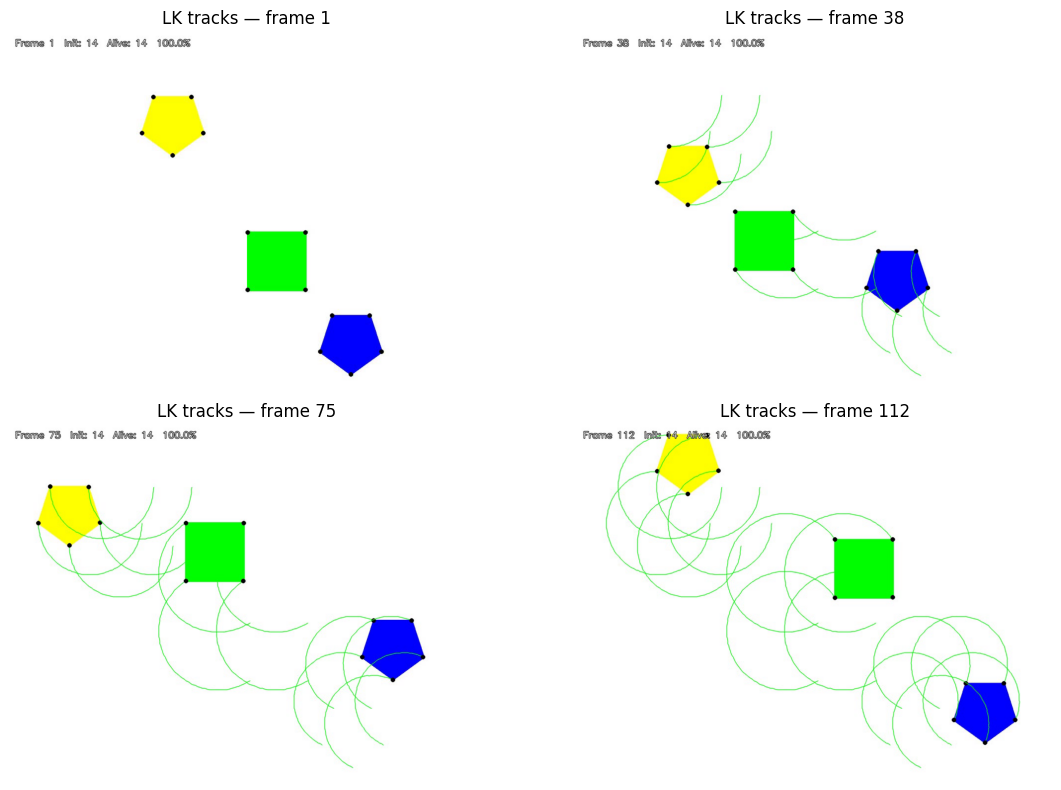

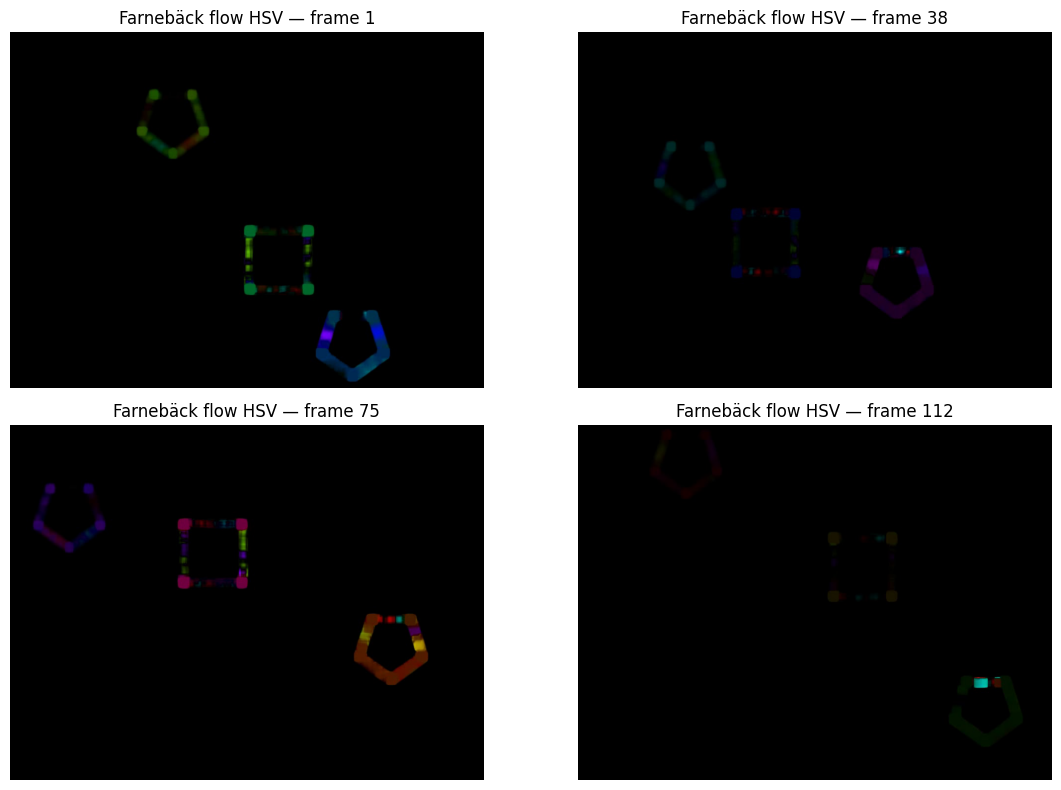

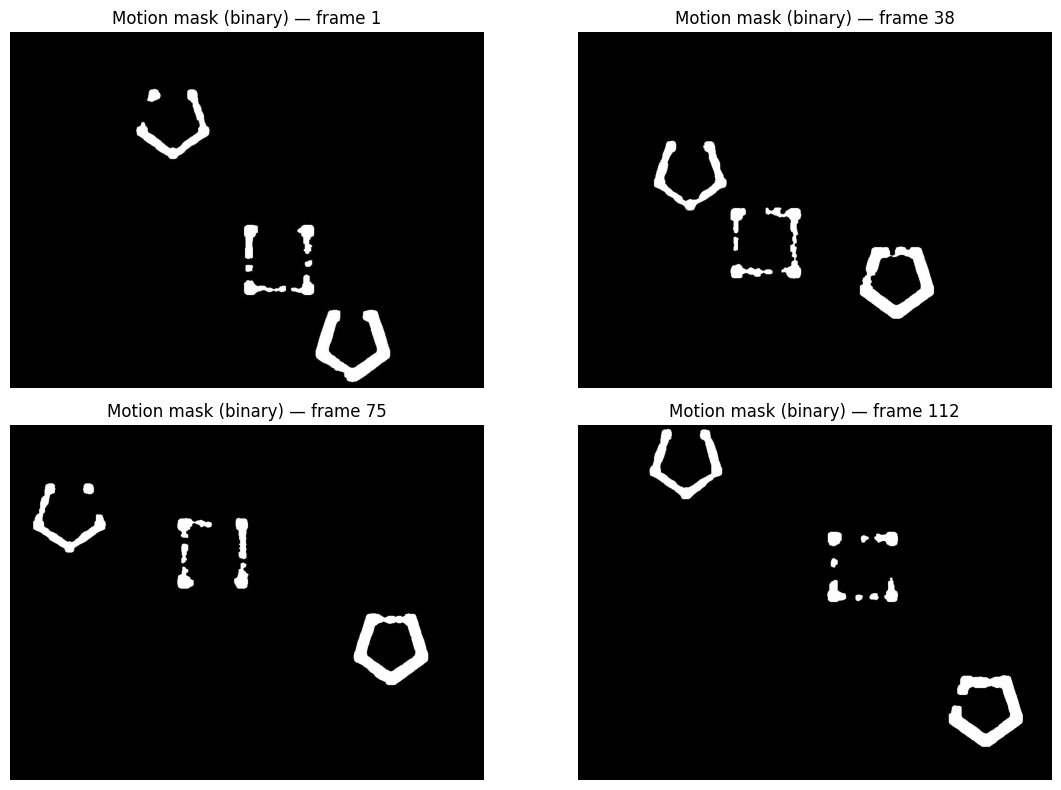

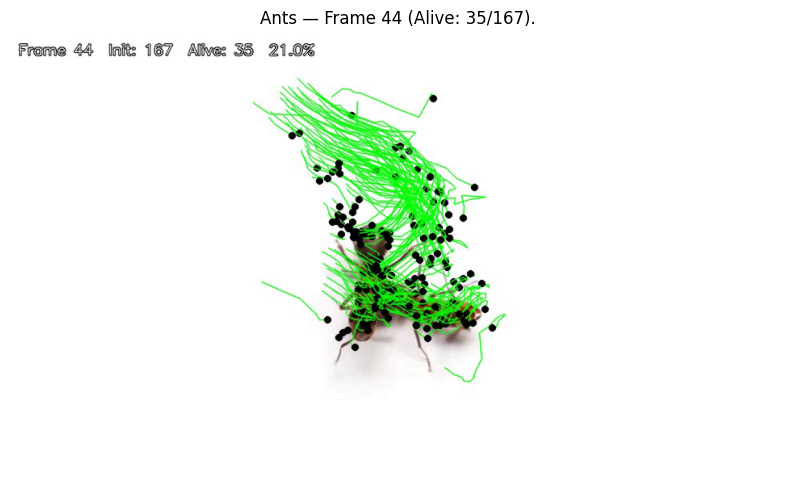

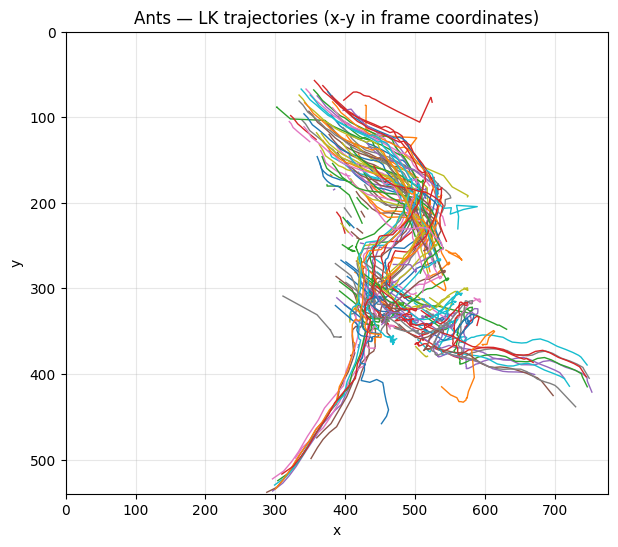

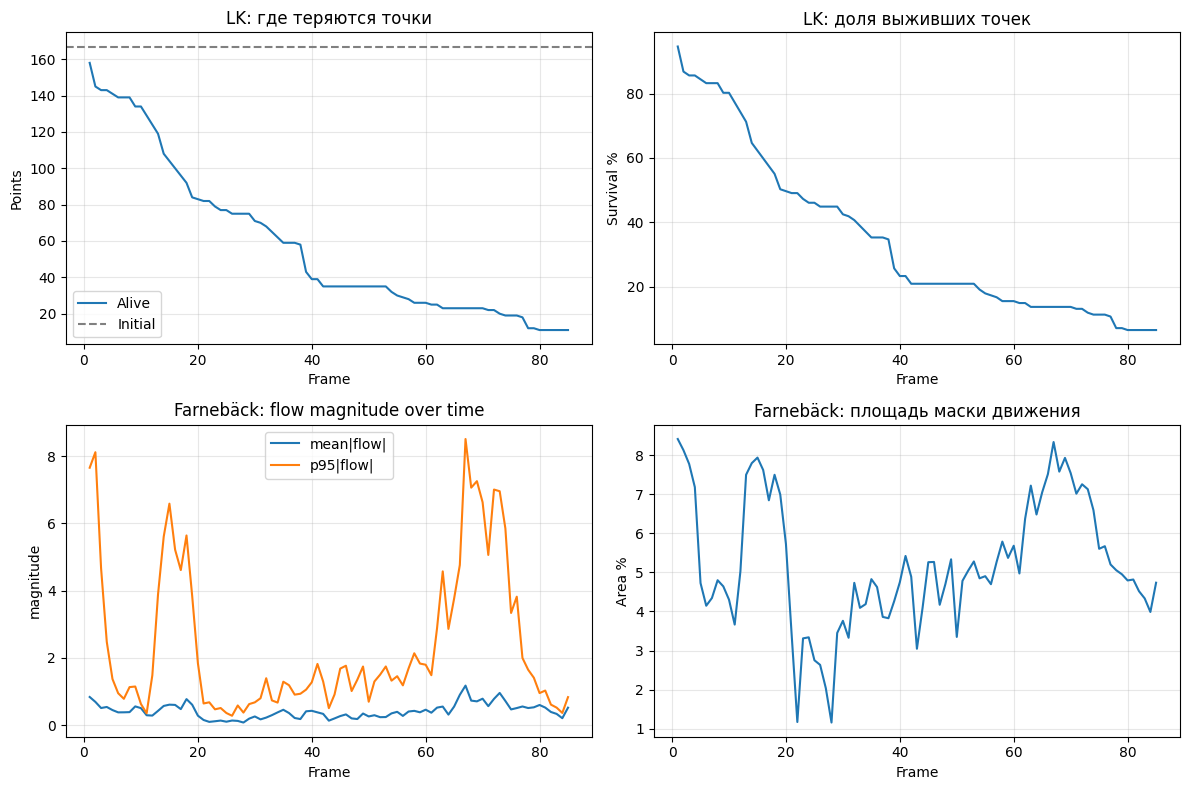

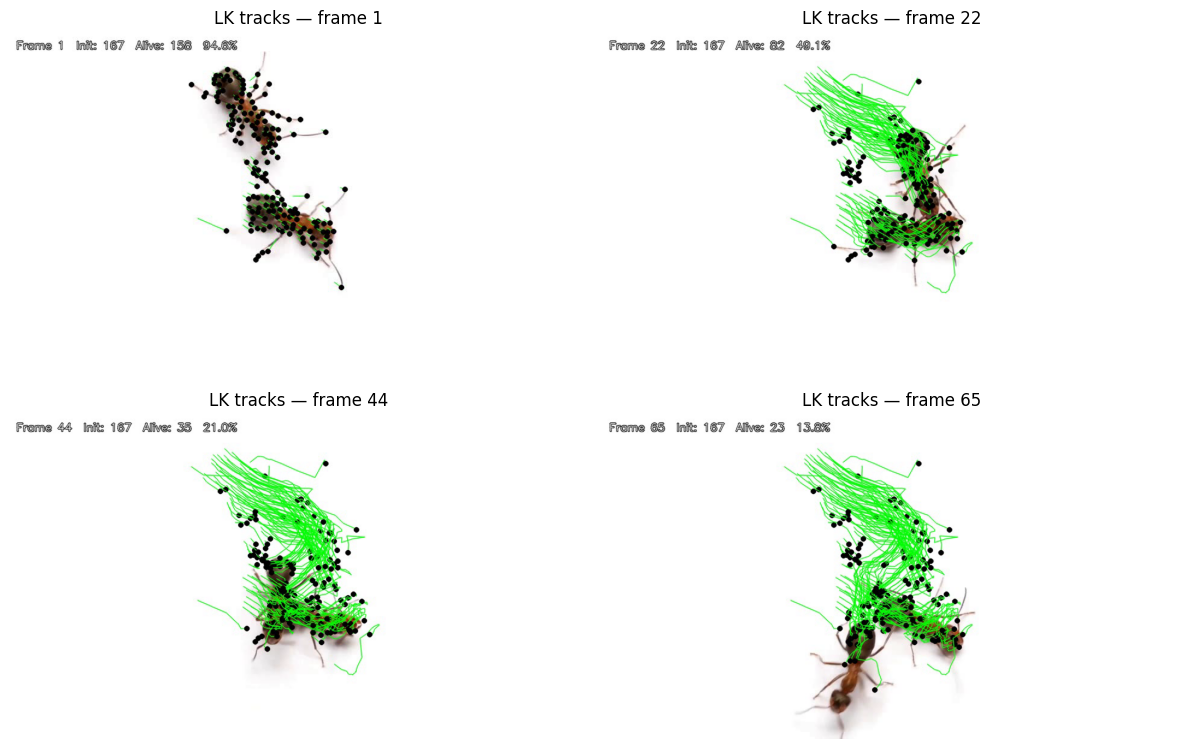

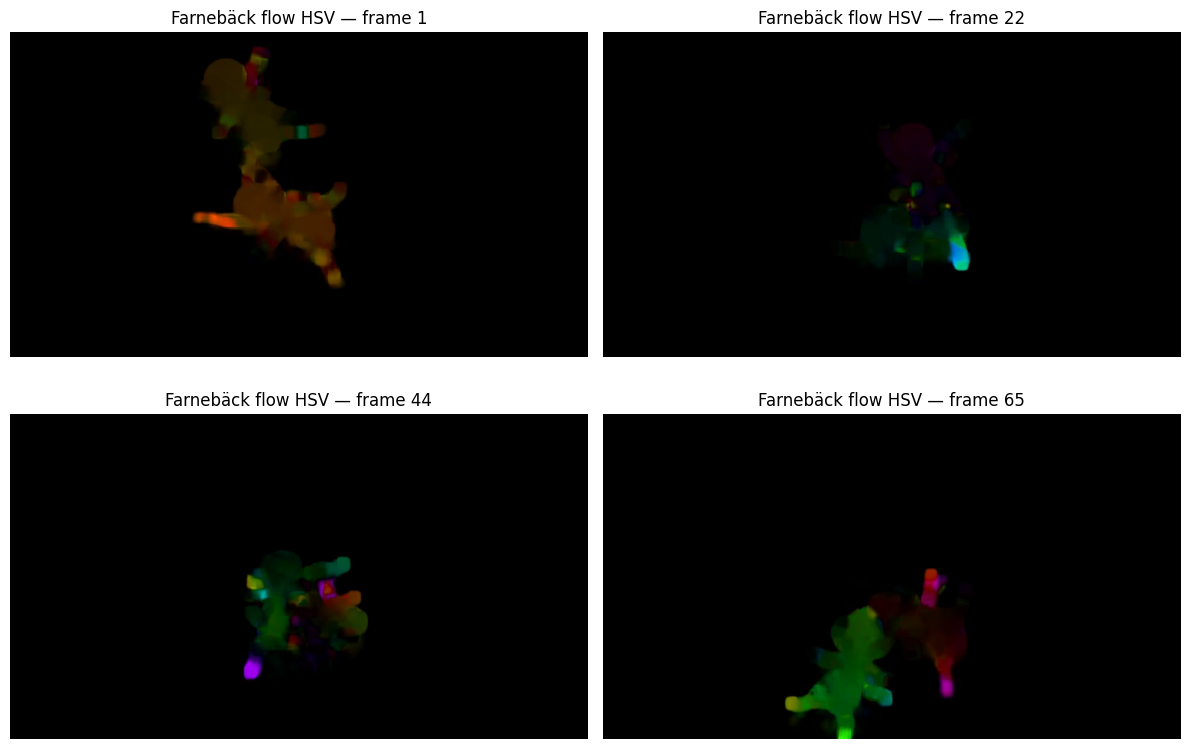

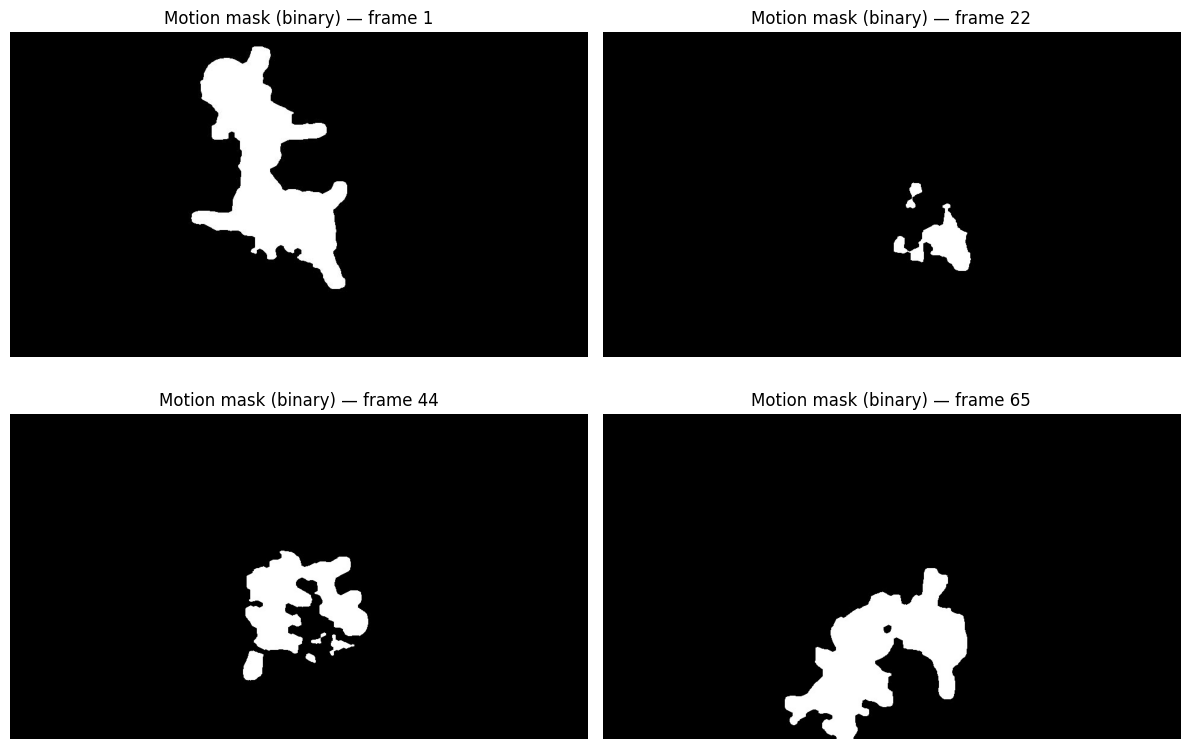

In [15]:
#visuals
ANTS_FRAME_TO_SHOW = 44
SHAPES_FRAME_TO_SHOW = 75

def plot_tracks_xy(tracks, H, title="LK trajectories in frame coords"):
    """Визуализация в координатах кадра"""
    plt.figure(figsize=(7, 6))
    for tr in tracks:
        if len(tr) < 2:
            continue
        xy = np.array(tr)
        plt.plot(xy[:, 0], xy[:, 1], linewidth=1)
    plt.gca().invert_yaxis()
    plt.xlim([0, None])
    plt.ylim([H, 0])
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    plt.show()

def _run_analysis_plots(name, r, frame_to_show, sample_frames_only=False):
    """Plots for one video. sample_frames_only=True → only 3 figures (4 frames each: LK tracks, flow HSV, motion mask).
    Otherwise also: single frame, trajectories, 2x2 metrics (alive, survival %, flow mag, mask area)."""
    fc = r["frame_count"]
    if not sample_frames_only:
        frames = np.arange(1, len(r["alive_counts"]) + 1)
        idx = max(0, min(frame_to_show - 1, fc - 1))
        lk_path = os.path.join(r["out_v"], "lk_tracks.avi")
        cap = cv2.VideoCapture(lk_path)
        if cap.isOpened():
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ok, img = cap.read()
            cap.release()
            if ok:
                n_alive = r["alive_counts"][idx] if idx < len(r["alive_counts"]) else 0
                plt.figure(figsize=(10, 6))
                plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                plt.title(f"{name} — Frame {idx+1} (Alive: {n_alive}/{r['n_initial']}).")
                plt.axis("off")
                plt.show()
        plot_tracks_xy(r["tracks"], r["height"], title=f"{name} — LK trajectories (x-y in frame coordinates)")
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        ax = axes[0, 0]
        ax.plot(frames, r["alive_counts"], label="Alive")
        ax.axhline(r["n_initial"], color="gray", linestyle="--", label="Initial")
        ax.set_xlabel("Frame"); ax.set_ylabel("Points"); ax.set_title("LK: где теряются точки")
        ax.legend(); ax.grid(True, alpha=0.3)
        ax = axes[0, 1]
        ax.plot(frames, np.array(r["survival_rates"]) * 100)
        ax.set_xlabel("Frame"); ax.set_ylabel("Survival %"); ax.set_title("LK: доля выживших точек")
        ax.grid(True, alpha=0.3)
        ax = axes[1, 0]
        ax.plot(frames, r["mean_mag"], label="mean|flow|"); ax.plot(frames, r["p95_mag"], label="p95|flow|")
        ax.set_xlabel("Frame"); ax.set_ylabel("magnitude"); ax.set_title("Farnebäck: flow magnitude over time")
        ax.legend(); ax.grid(True, alpha=0.3)
        ax = axes[1, 1]
        ax.plot(frames, np.array(r["mask_area_ratios"]) * 100)
        ax.set_xlabel("Frame"); ax.set_ylabel("Area %"); ax.set_title("Farnebäck: площадь маски движения")
        ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()
    
    sample_idx = [min(i, fc - 1) for i in [0, fc // 4, fc // 2, (3 * fc) // 4]]
    for fname, cmap, title_prefix in [
        ("lk_tracks.avi", None, "LK tracks"),
        ("farneback_flow.avi", None, "Farnebäck flow HSV"),
        ("motion_mask.avi", "gray", "Motion mask (binary)"),
    ]:
        path = os.path.join(r["out_v"], fname)
        cap = cv2.VideoCapture(path)
        if not cap.isOpened(): continue
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        for ax, si in zip(axes.ravel(), sample_idx):
            cap.set(cv2.CAP_PROP_POS_FRAMES, si)
            ok, img = cap.read()
            if not ok:
                ax.text(0.5, 0.5, f"Frame {si + 1} (read failed)", ha="center", va="center", transform=ax.transAxes)
                ax.axis("off"); continue
            if cmap == "gray":
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                ax.imshow(img, cmap="gray")
            else:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(f"{title_prefix} — frame {si + 1}"); ax.axis("off")
        cap.release(); plt.tight_layout(); plt.show()

if "shapes" in results and results["shapes"] is not None:
    _run_analysis_plots("Shapes", results["shapes"], SHAPES_FRAME_TO_SHOW, sample_frames_only=True)

if "ants" in results and results["ants"] is not None:
    _run_analysis_plots("Ants", results["ants"], ANTS_FRAME_TO_SHOW)
else:
    print("Run VIDEO_LIST with ants first.")

### Качественный и количественный разбор ошибок  
**Вариант B: система анализа движения**

В работе сначала было протестировано **видео с геометрическими фигурами** но оно оказалась слишком простым: объекты имеют чёткие границы, однотонный фон, практически отсутствуют шум, перекрытия и сложные деформации. Поэтому в этом ролике точки, найденные методом **Lucas–Kanade** не терялись, а оба алгоритма работали близко к идеальному случаю. Поэтому использовалось более сложное **видео с муравьями**, где потеря точек происходит и хорошо видны различия между методами.

---

## Домашнее задание 1  
### Оптический поток и динамика видео  
**Вариант B: учебная система анализа движения**

В работе были протестированы **два видео**:

1. Видео с геометрическими фигурами  
2. Видео с муравьями  

Сначала планиировалось использовать видео с фигурами. Однако оно оказалось **слишком простым**: объекты имеют чёткие границы, высокий контраст и отсутствуют перекрытия. Поэтому **метод Lucas–Kanade практически не теряет точки**, и оба алгоритма работают почти идеально.

Чтобы увидеть реальные ограничения методов, был использован второй ролик — **видео с муравьями**, где наблюдаются перекрытия объектов, сложная динамика движения и шум. Именно на этом видео можно увидеть, где и почему методы начинают ошибаться.

---

## 1. Цель работы

Целью работы было реализовать модуль анализа движения на основе двух методов оптического потока:

- **Lucas–Kanade (LK)** — разреженный оптический поток  
- **Farnebäck** — плотный оптический поток  

В рамках работы необходимо было:

- найти ключевые точки и отслеживать их методом Lucas–Kanade;
- построить **траектории движения**;
- вычислить **плотное поле движения** методом Farnebäck;
- построить **карты оптического потока**;
- выделить **движущиеся области**;
- получить **бинарные маски движения**;
- сравнить устойчивость методов.

---

## 2. Используемые методы

### Lucas–Kanade

Метод **Lucas–Kanade** вычисляет **разреженный оптический поток**, то есть отслеживает движение только выбранных ключевых точек, а не каждого пикселя изображения.

Алгоритм работы следующий:

1. На первом кадре находятся **характерные точки** (углы Shi–Tomasi).
2. Для каждого следующего кадра вычисляется смещение этих точек.
3. Последовательность положений формирует **траектории движения**.
4. Если точка перестаёт надёжно сопоставляться между кадрами, она считается потерянной.

Преимущества метода:

- позволяет строить устойчивые и интерпретируемые **траектории движения**;
- работает достаточно быстро;
- хорошо подходит для **небольших смещений** между кадрами.

Недостатки:

- сильно зависит от **качества текстуры**;
- точки могут **теряться при перекрытиях объектов**.

---

### Farnebäck

Метод **Farnebäck** вычисляет **плотный оптический поток**, то есть оценивает движение **для каждого пикселя изображения**.

В работе были построены:

- **HSV-визуализации потока**;
- **карты величины движения**;
- **бинарные маски движения**.

В HSV-визуализации:

- **Hue** кодирует направление движения;
- **Value** кодирует величину движения.

Преимущества метода:

- позволяет анализировать движение **по всему изображению**;
- не зависит от конкретного набора ключевых точек.

Недостатки:

- более чувствителен к **шуму**;
- может давать **фрагментированные или нестабильные маски движения**.

---

## 3. Эксперимент 1 — видео с фигурами

В первом видео наблюдаются три движущиеся геометрические фигуры.

Особенности сцены:

- статичный фон;
- высокая контрастность объектов;
- чёткие границы;
- отсутствуют перекрытия;
- движение плавное.

### Lucas–Kanade

Метод обнаружил **14 ключевых точек** (что логично, т.к. на видео 2 пятиугольника и квадрат).  
Во всех показанных кадрах все точки выживают.

Таким образом, для синтетической сцены **Lucas–Kanade работает идеально**.

### Farnebäck

Плотный поток также корректно определяет движение фигур.

Наблюдения:

- цветовые карты хорошо показывают **направление движения**;
- движение локализуется на **границах объектов**;
- бинарные маски выделяют **движущиеся контуры фигур**.

Однако видно, что Farnebäck реагирует прежде всего на **изменения яркости**, поэтому в основном выделяются именно границы объектов, а не вся фигура целиком.

---

## 4. Эксперимент 2 — видео с муравьями

Усложним задачу и рассмотрим видео с муравьями.

Особенности сцены:

- большое количество малых деталей (ноги, антенны)
- муравьи **проползают друг по другу**, что приводит к перекрытию, выходят из кадра;
- форма объектов **деформируется**;
- быстрые движения конечностей, присутствует **motion blur**;
- текстуры у объектов похожи.

Все эти факторы усложняют задачу оценки оптического потока.

---

## 5. Lucas–Kanade на видео с муравьями

На первом кадре было найдено:

**Initial points = 167**

Со временем количество отслеживаемых точек уменьшается.

Примеры:

| Frame | Alive | Survival |
|------|------|------|
| 1 | 158 | 94.6% |
| 22 | 82 | 49.1% |
| 44 | 35 | 21.0% |
| 65 | 23 | 13.8% |

Т.е. по причинам указанным выше, **количество точек быстро уменьшается по мере продвижения по видео**.
Наибольшая потеря точек происходит примерно в середине видео ввиду перекрытия.

---

## 6. Farnebäck на видео с муравьями

### Плотный поток

HSV-визуализация показывает движение по всей области видео.  
Однако поток становится более шумным:

- внутри одного муравья могут появляться разные направления;
- появляются локальные цветовые артефакты;
- часть потока может появляться на фоне.

### Бинарные маски движения

Маски движения получаются путём пороговой обработки величины потока.

Наблюдаются следующие эффекты:

- **фрагментация маски**;
- **слияние муравьёв в одну область**;
- нестабильный размер области движения.

Это связано с тем, что разные части объектов могут двигаться с разной скоростью.

---

## 7. Количественный анализ (см. графики выше)

### Выживаемость точек LK

График показывает постепенное уменьшение количества отслеживаемых точек.  
Основные потери происходят во время перекрытия и быстрого движения.

### Величина оптического потока

Средняя величина потока остаётся относительно стабильной.  
Однако **95-й процентиль** показывает всплески — моменты более быстрого движения.

### Площадь маски движения

Площадь маски заметно колеблется.

---

## 8. Сравнение методов

### Чувствительность к текстуре

**Lucas–Kanade**

- сильно зависит от качества текстуры;
- может терять точки на однородных участках.

**Farnebäck**

- менее зависит от отдельных признаков;
- но может давать менее точные направления движения.

### Чувствительность к motion blur

**Lucas–Kanade** часто теряет точки при сильном размытии.  
**Farnebäck** обычно всё ещё показывает движение, но становится более шумным.


### Чувствительность к шуму

**Farnebäck** может создавать ложные поля движения (видно на видео с фигурами).  
**Lucas–Kanade** чаще просто теряет отдельные точки.

---

## 9. Когда выбирать каждый метод

### Lucas–Kanade

Подходит для:

- анализа **траекторий движения**;
- отслеживания **ключевых точек**;
- анализа движения отдельных объектов.

### Farnebäck

Подходит для:

- построения **поля движения**;
- выделения **движущихся областей**;
- сегментации движения.

---

## 10. Итог

Были протестированы два видео.

### Видео с фигурами

- сцена слишком простая;
- **Lucas–Kanade не теряет точки**;
- Farnebäck показывает достаточно чистое поле движения.

### Видео с муравьями

Сложная сцена подсвечивает реальные ограничения методов.

**Lucas–Kanade** теряет точки из-за:

- перекрытий муравьёв;
- однородной текстуры;
- деформаций объектов;
- motion blur;
- накопления ошибки.

**Farnebäck**:

- показывает движение по всей области;
- но создаёт шум, маски движения могут быть нестабильны.

---

## Итоговый вывод

- **Lucas–Kanade** лучше подходит для анализа **траекторий точек**.  
- **Farnebäck** лучше подходит для анализа **общего поля движения**.

В реальных задачах эти методы логично **использовать совместно**.